## Setup — Load and Inspect Results

Imports standard analysis libraries, configures the plot theme, and loads the benchmark
results CSV produced by `run_bench.py`.  
Update `RESULTS_CSV` below to point at your results file before running.
A quick status breakdown is printed so you can see how many cases completed successfully
vs. hit the timeout/OOM/error limits.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="colorblind")
RESULTS_CSV = "results/results.csv"  # Update to full results path

df = pd.read_csv(RESULTS_CSV)
ok = df[df["status"] == "ok"].copy()
print(f"Total rows: {len(df)}, ok: {len(ok)}, non-ok: {len(df) - len(ok)}")
print(df["status"].value_counts().to_string())

Total rows: 284, ok: 222, non-ok: 62
status
ok         222
oom         45
error       12
timeout      5


## Plot 1 — Scaling vs. Number of Formulas (n)

Shows how total translation time and semi-automaton size grow as the number of LTLf
formulas `n` increases, while holding `|AP| = 3`, `formula_size = 5`, and
`density = medium` fixed.  
Each point is the mean over 5 random seeds; error bars show ±1 standard deviation.
The right y-axis (orange) tracks the mean number of semi-automaton states, which
is the primary driver of translation cost.

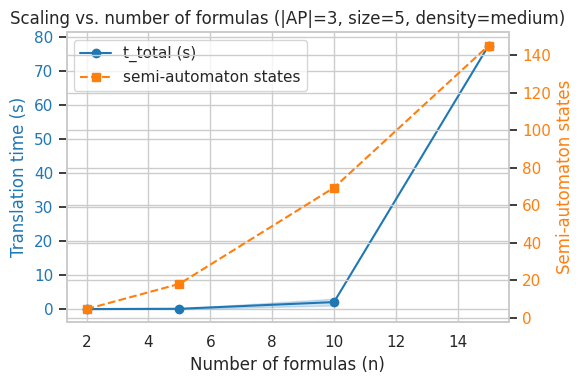

In [2]:
subset = ok[(ok["num_aps"] == 3) & (ok["formula_size"] == 5) & (ok["density"] == "medium")]
agg = subset.groupby("n").agg(
    t_mean=("t_total", "mean"), t_std=("t_total", "std"),
    states_mean=("semi_states", "mean")
).reset_index()

fig, ax1 = plt.subplots(figsize=(6, 4))
line1, = ax1.plot(agg["n"], agg["t_mean"], marker="o", color="tab:blue", label="t_total (s)")
ax1.fill_between(agg["n"],
                 agg["t_mean"] - agg["t_std"],
                 agg["t_mean"] + agg["t_std"],
                 alpha=0.2, color="tab:blue")
ax1.set_xlabel("Number of formulas (n)")
ax1.set_ylabel("Translation time (s)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
line2, = ax2.plot(agg["n"], agg["states_mean"], marker="s", linestyle="--",
                  color="tab:orange", label="semi-automaton states")
ax2.set_ylabel("Semi-automaton states", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

ax1.set_title("Scaling vs. number of formulas (|AP|=3, size=5, density=medium)")
ax1.legend(handles=[line1, line2], loc="upper left")
fig.tight_layout()
plt.savefig("results/plot_scaling_n.pdf", bbox_inches="tight")
plt.show()

## Plot 2 — Scaling vs. Atomic Propositions (|AP|)

Isolates the effect of the alphabet size on translation cost.  
Fixed parameters: `n = 5`, `formula_size = 5`, `density = medium`.  
Larger |AP| exponentially increases the number of alphabet symbols the
semi-automaton must enumerate, so even modest growth in |AP| can dominate
runtime for edge-enumeration approaches.

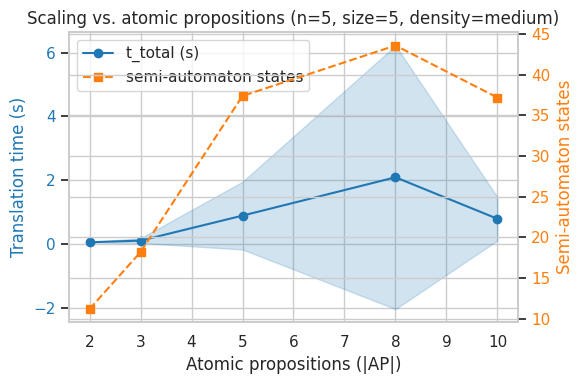

In [3]:
subset = ok[(ok["n"] == 5) & (ok["formula_size"] == 5) & (ok["density"] == "medium")]
agg = subset.groupby("num_aps").agg(
    t_mean=("t_total", "mean"), t_std=("t_total", "std"),
    states_mean=("semi_states", "mean")
).reset_index()

fig, ax1 = plt.subplots(figsize=(6, 4))
line1, = ax1.plot(agg["num_aps"], agg["t_mean"], marker="o", color="tab:blue", label="t_total (s)")
ax1.fill_between(agg["num_aps"],
                 agg["t_mean"] - agg["t_std"],
                 agg["t_mean"] + agg["t_std"],
                 alpha=0.2, color="tab:blue")
ax1.set_xlabel("Atomic propositions (|AP|)")
ax1.set_ylabel("Translation time (s)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
line2, = ax2.plot(agg["num_aps"], agg["states_mean"], marker="s", linestyle="--",
                  color="tab:orange", label="semi-automaton states")
ax2.set_ylabel("Semi-automaton states", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

ax1.set_title("Scaling vs. atomic propositions (n=5, size=5, density=medium)")
ax1.legend(handles=[line1, line2], loc="upper left")
fig.tight_layout()
plt.savefig("results/plot_scaling_aps.pdf", bbox_inches="tight")
plt.show()

## Plot 3 — Scaling vs. Formula Size

Shows the effect of increasing per-formula complexity (measured as the maximum
operator-tree size passed to `spot.randltl`).  
Fixed parameters: `n = 5`, `|AP| = 3`, `density = medium`.  
Larger formulas produce larger DFAs per formula (Stage 1 cost), but the
product-construction cost (Stage 2) grows with the *product* of DFA sizes,
so this axis can interact non-linearly with `n`.

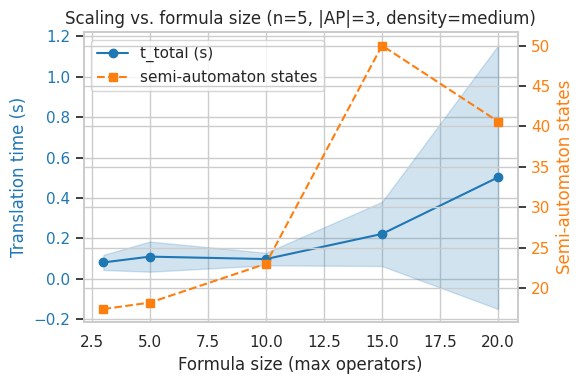

In [4]:
subset = ok[(ok["n"] == 5) & (ok["num_aps"] == 3) & (ok["density"] == "medium")]
agg = subset.groupby("formula_size").agg(
    t_mean=("t_total", "mean"), t_std=("t_total", "std"),
    states_mean=("semi_states", "mean")
).reset_index()

fig, ax1 = plt.subplots(figsize=(6, 4))
line1, = ax1.plot(agg["formula_size"], agg["t_mean"], marker="o", color="tab:blue", label="t_total (s)")
ax1.fill_between(agg["formula_size"],
                 agg["t_mean"] - agg["t_std"],
                 agg["t_mean"] + agg["t_std"],
                 alpha=0.2, color="tab:blue")
ax1.set_xlabel("Formula size (max operators)")
ax1.set_ylabel("Translation time (s)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
line2, = ax2.plot(agg["formula_size"], agg["states_mean"], marker="s", linestyle="--",
                  color="tab:orange", label="semi-automaton states")
ax2.set_ylabel("Semi-automaton states", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

ax1.set_title("Scaling vs. formula size (n=5, |AP|=3, density=medium)")
ax1.legend(handles=[line1, line2], loc="upper left")
fig.tight_layout()
plt.savefig("results/plot_scaling_fsize.pdf", bbox_inches="tight")
plt.show()

## Plot 4 — Effect of Partial Order Density

Compares the four density levels (sparse 20%, medium 50%, dense 80%, total 100%)
at the baseline structural configuration: `n = 5`, `|AP| = 3`, `formula_size = 5`.  
Translation time and semi-automaton states are shown as absolute values; preference
graph edges are normalised to [0, 1] for comparability on the same axis.  
Denser partial orders increase preference-graph complexity but generally have little
effect on semi-automaton construction time.

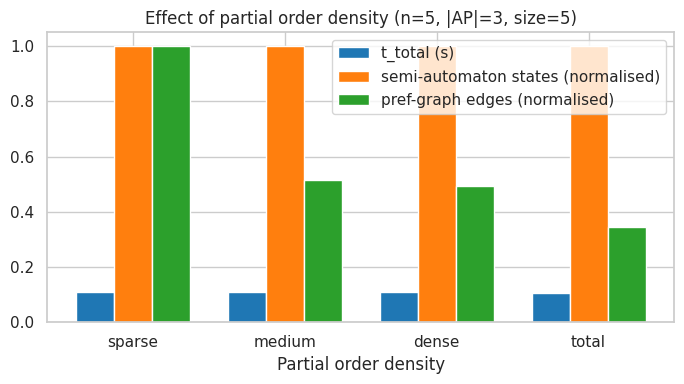

In [5]:
subset = ok[(ok["n"] == 5) & (ok["num_aps"] == 3) & (ok["formula_size"] == 5)]
agg = subset.groupby("density").agg(
    t_mean=("t_total", "mean"),
    states_mean=("semi_states", "mean"),
    pref_edges_mean=("pref_edges", "mean"),
).reset_index()

density_order = ["sparse", "medium", "dense", "total"]
agg["density"] = pd.Categorical(agg["density"], categories=density_order, ordered=True)
agg = agg.sort_values("density")

x = np.arange(len(agg))
width = 0.25
fig, ax = plt.subplots(figsize=(7, 4))
bars1 = ax.bar(x - width, agg["t_mean"], width, label="t_total (s)", color="tab:blue")
bars2 = ax.bar(x, agg["states_mean"] / agg["states_mean"].max(), width,
               label="semi-automaton states (normalised)", color="tab:orange")
bars3 = ax.bar(x + width, agg["pref_edges_mean"] / (agg["pref_edges_mean"].max() + 1e-9), width,
               label="pref-graph edges (normalised)", color="tab:green")
ax.set_xticks(x)
ax.set_xticklabels(agg["density"])
ax.set_xlabel("Partial order density")
ax.set_title("Effect of partial order density (n=5, |AP|=3, size=5)")
ax.legend()
fig.tight_layout()
plt.savefig("results/plot_density.pdf", bbox_inches="tight")
plt.show()

## Plot 5 — Pipeline Stage Breakdown vs. n

Stacked bar chart decomposing total translation time into three pipeline stages:
- **t_dfa**: time to convert each LTLf formula to a DFA via MONA
- **t_semi**: time to build the product semi-automaton
- **t_pref**: time to build the preference graph from the semi-automaton

Fixed parameters: `|AP| = 3`, `formula_size = 5`, `density = medium`.  
This plot identifies which stage dominates and at what value of `n` the bottleneck shifts.

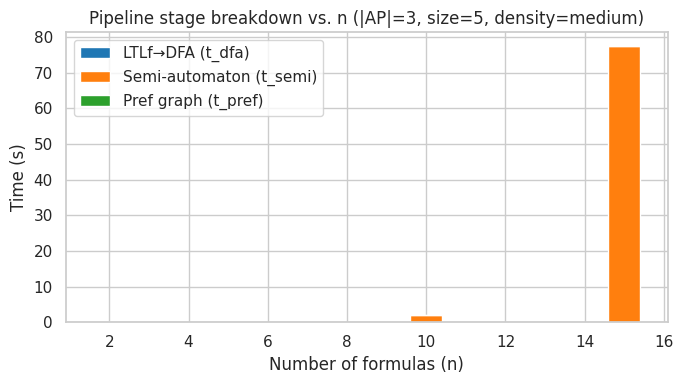

In [6]:
subset = ok[(ok["num_aps"] == 3) & (ok["formula_size"] == 5) & (ok["density"] == "medium")]
agg = subset.groupby("n").agg(
    t_dfa=("t_dfa", "mean"), t_semi=("t_semi", "mean"), t_pref=("t_pref", "mean")
).reset_index()

fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(agg["n"], agg["t_dfa"], label="LTLf\u2192DFA (t_dfa)", color="tab:blue")
b2 = ax.bar(agg["n"], agg["t_semi"], bottom=agg["t_dfa"],
            label="Semi-automaton (t_semi)", color="tab:orange")
b3 = ax.bar(agg["n"], agg["t_pref"], bottom=agg["t_dfa"] + agg["t_semi"],
            label="Pref graph (t_pref)", color="tab:green")
ax.set_xlabel("Number of formulas (n)")
ax.set_ylabel("Time (s)")
ax.set_title("Pipeline stage breakdown vs. n (|AP|=3, size=5, density=medium)")
ax.legend()
fig.tight_layout()
plt.savefig("results/plot_stage_breakdown.pdf", bbox_inches="tight")
plt.show()

## Plot 6 — Peak RAM Usage vs. n

Two memory metrics are plotted against the number of formulas `n`
(fixed `|AP| = 3`, `formula_size = 5`, `density = medium`):

- **peak_mem_mb** (tracemalloc): peak Python-heap allocation during `translate()`.
  Captures NumPy arrays, NetworkX graphs, and other Python objects, but does *not*
  include memory used by MONA subprocesses.
- **max_rss_mb** (OS RSS): maximum resident set size of the worker process as
  reported by `resource.getrusage()` on Linux/WSL. Includes all memory — Python
  heap, C extensions, and inherited pages — giving the true process-level peak.

The gap between the two curves indicates how much memory is consumed outside
the Python heap (primarily by the `ltlf2dfa` / MONA backend).

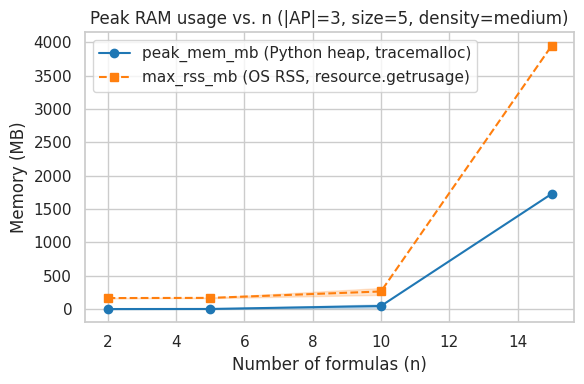

In [7]:
subset = ok[(ok["num_aps"] == 3) & (ok["formula_size"] == 5) & (ok["density"] == "medium")]
agg = subset.groupby("n").agg(
    py_mean=("peak_mem_mb", "mean"), py_std=("peak_mem_mb", "std"),
    rss_mean=("max_rss_mb", "mean"), rss_std=("max_rss_mb", "std"),
).reset_index()

fig, ax = plt.subplots(figsize=(6, 4))
line1, = ax.plot(agg["n"], agg["py_mean"], marker="o", color="tab:blue",
                 label="peak_mem_mb (Python heap, tracemalloc)")
ax.fill_between(agg["n"],
                agg["py_mean"] - agg["py_std"],
                agg["py_mean"] + agg["py_std"],
                alpha=0.2, color="tab:blue")
line2, = ax.plot(agg["n"], agg["rss_mean"], marker="s", linestyle="--", color="tab:orange",
                 label="max_rss_mb (OS RSS, resource.getrusage)")
ax.fill_between(agg["n"],
                agg["rss_mean"] - agg["rss_std"],
                agg["rss_mean"] + agg["rss_std"],
                alpha=0.2, color="tab:orange")
ax.set_xlabel("Number of formulas (n)")
ax.set_ylabel("Memory (MB)")
ax.set_title("Peak RAM usage vs. n (|AP|=3, size=5, density=medium)")
ax.legend()
fig.tight_layout()
plt.savefig("results/plot_ram_vs_n.pdf", bbox_inches="tight")
plt.show()

## Plot 7 — Success-Rate Heatmap (n × |AP|)

A heatmap showing what fraction of cases completed successfully (status = `ok`)
for each combination of `n` and `|AP|`, aggregated across all density levels,
formula sizes, and seeds.  
Red cells indicate parameter combinations where the translation consistently
fails or times out, marking the practical feasibility boundary of the procedure.

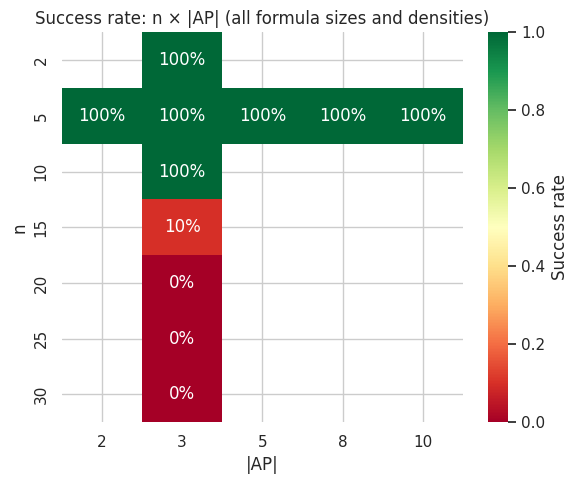

In [8]:
heat = df.groupby(["n", "num_aps"]).apply(
    lambda g: (g["status"] == "ok").mean()
).reset_index(name="success_rate")
pivot = heat.pivot(index="n", columns="num_aps", values="success_rate")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt=".0%", cmap="RdYlGn", vmin=0, vmax=1, ax=ax,
            cbar_kws={"label": "Success rate"})
ax.set_title("Success rate: n \u00d7 |AP| (all formula sizes and densities)")
ax.set_xlabel("|AP|")
ax.set_ylabel("n")
fig.tight_layout()
plt.savefig("results/plot_heatmap.pdf", bbox_inches="tight")
plt.show()

## Diagnostic — OOM Cases

Lists all cases that were killed by the OS due to exceeding the per-worker RAM cap
(`--mem-limit-mb`).  These cases define the memory boundary of the procedure and
are useful for understanding which parameter combinations require more than the
allocated RAM budget.

Columns shown: `case_id`, `n`, `num_aps`, `formula_size`, `density`.

In [9]:
oom = df[df["status"] == "oom"][["case_id", "n", "num_aps", "formula_size", "density"]].copy()
print(f"OOM cases: {len(oom)}")
if len(oom) > 0:
    print(oom.to_string(index=False))
else:
    print("  (none — all cases stayed within the RAM cap)")

OOM cases: 45
              case_id  n  num_aps  formula_size density
n15_ap3_sz5_sparse_s1 15        3             5  sparse
n15_ap3_sz5_medium_s1 15        3             5  medium
n15_ap3_sz5_sparse_s2 15        3             5  sparse
n15_ap3_sz5_medium_s2 15        3             5  medium
 n15_ap3_sz5_dense_s1 15        3             5   dense
 n15_ap3_sz5_total_s1 15        3             5   total
 n15_ap3_sz5_dense_s3 15        3             5   dense
 n15_ap3_sz5_total_s0 15        3             5   total
n20_ap3_sz5_sparse_s0 20        3             5  sparse
n20_ap3_sz5_sparse_s1 20        3             5  sparse
n20_ap3_sz5_sparse_s2 20        3             5  sparse
n20_ap3_sz5_sparse_s3 20        3             5  sparse
n20_ap3_sz5_sparse_s4 20        3             5  sparse
n20_ap3_sz5_medium_s0 20        3             5  medium
n20_ap3_sz5_medium_s1 20        3             5  medium
n20_ap3_sz5_medium_s2 20        3             5  medium
n20_ap3_sz5_medium_s3 20        3 

## Diagnostic — Timeout Cases

Lists all cases that exceeded the per-worker time limit (`--timeout`).  
Together with the OOM table above, this identifies the frontier beyond which
the translation procedure is not practical under the given resource limits.

Columns shown: `case_id`, `n`, `num_aps`, `formula_size`, `density`.

In [10]:
timeouts = df[df["status"] == "timeout"][["case_id", "n", "num_aps", "formula_size", "density"]].copy()
print(f"Timeout cases: {len(timeouts)}")
if len(timeouts) > 0:
    print(timeouts.to_string(index=False))
else:
    print("  (none — all cases completed within the time limit)")

Timeout cases: 5
              case_id  n  num_aps  formula_size density
n15_ap3_sz5_sparse_s3 15        3             5  sparse
n15_ap3_sz5_medium_s0 15        3             5  medium
n15_ap3_sz5_medium_s3 15        3             5  medium
 n15_ap3_sz5_total_s2 15        3             5   total
 n30_ap3_sz5_dense_s2 30        3             5   dense


## Summary Table

Aggregated statistics for every parameter combination that produced at least one
successful run.  Columns:
- **mean_t_total** — average wall-clock translation time (s)
- **mean_semi_states** — average number of semi-automaton states
- **mean_pref_nodes** — average number of preference-graph nodes (equivalence classes)
- **mean_peak_mem_mb** — average Python-heap peak (MB)
- **mean_max_rss_mb** — average OS RSS peak (MB)
- **success_pct** — percentage of seeds that completed within the resource limits

The table is also written to `results/summary_table.csv` for use in papers or reports.

In [11]:
summary = ok.groupby(["n", "num_aps", "formula_size", "density"]).agg(
    mean_t_total=("t_total", "mean"),
    mean_semi_states=("semi_states", "mean"),
    mean_pref_nodes=("pref_nodes", "mean"),
    mean_peak_mem_mb=("peak_mem_mb", "mean"),
    mean_max_rss_mb=("max_rss_mb", "mean"),
).round(3).reset_index()

total_per_combo = df.groupby(["n", "num_aps", "formula_size", "density"]).size().reset_index(name="total")
ok_per_combo = ok.groupby(["n", "num_aps", "formula_size", "density"]).size().reset_index(name="ok_count")
rate = total_per_combo.merge(ok_per_combo, how="left").fillna(0)
rate["success_pct"] = (rate["ok_count"] / rate["total"] * 100).round(1)

summary = summary.merge(rate[["n", "num_aps", "formula_size", "density", "success_pct"]], how="left")
print(summary.to_string(index=False))
summary.to_csv("results/summary_table.csv", index=False)

 n  num_aps  formula_size density  mean_t_total  mean_semi_states  mean_pref_nodes  mean_peak_mem_mb  mean_max_rss_mb  success_pct
 2        3             5   dense         0.030               4.8              2.6             0.188          165.032        100.0
 2        3             5  medium         0.033               4.8              2.6             0.188          164.715        100.0
 2        3             5  sparse         0.031               4.8              2.8             0.189          164.557        100.0
 2        3             5   total         0.033               4.8              2.2             0.188          164.944        100.0
 5        2             5   dense         0.046              11.2              2.2             0.241          165.116        100.0
 5        2             5  medium         0.058              11.2              2.2             0.241          165.095        100.0
 5        2             5  sparse         0.050              11.2              4.6 